# Everest Death zone summit prediction model.
A logical regression model to predict whether a climber can successfully summit the mount everest.

\- Step 1: Import the dataset, and required modules.

In [199]:
#importing the required libraries
import pandas as pd #for ops on dataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder #for data transformation
from numpy import set_printoptions #to fit the model.
import numpy as np #for numerical ops
import matplotlib.pyplot as plt #for data visualization
import seaborn as sns
from sklearn.linear_model import LogisticRegression #logistic model
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve #to evaluate the accuracy of the model
from sklearn.model_selection import train_test_split #splitting the data
from sklearn.feature_selection import RFE #Recursive feature elimination
from sklearn.model_selection import cross_val_score #cross validation


In [200]:
#now, getting the dataset.
df = pd.read_csv("everest_summit_master.csv")

In [201]:
df.head()

,climber_id,year,season,route,age,sex,is_hired_staff,years_climbing,prior_8000m_peaks,prior_everest_attempts,...,o2_start_altitude_m,days_acclimatizing,camps_established,summit_window_days,weather_score,jetstream_risk,queue_minutes_above_8000,turnaround_reason,serious_incident,summited
0,CLB000000,2025,spring,South Col-SE Ridge,56,M,0,15,0,1,...,7000,29,6,5,10.0,1.3,120,other,0,0
1,CLB000001,2020,spring,North Ridge-NE,47,M,0,7,0,1,...,7900,27,4,5,4.8,4.7,26,summited,0,1
2,CLB000002,2022,autumn,South Col-SE Ridge,24,M,1,19,1,0,...,7000,29,3,3,8.6,1.6,37,summited,0,1
3,CLB000003,2024,spring,South Col-SE Ridge,50,F,0,12,3,0,...,7000,35,2,6,5.9,3.0,45,team_decision,0,0
4,CLB000004,2015,spring,North Ridge-NE,60,F,0,1,1,0,...,7300,20,1,7,6.7,2.7,20,exhaustion_altitude_sickness,0,0


In [202]:
#Exploring the data:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   climber_id                45000 non-null  object 
 1   year                      45000 non-null  int64  
 2   season                    45000 non-null  object 
 3   route                     45000 non-null  object 
 4   age                       45000 non-null  int64  
 5   sex                       45000 non-null  object 
 6   is_hired_staff            45000 non-null  int64  
 7   years_climbing            45000 non-null  int64  
 8   prior_8000m_peaks         45000 non-null  int64  
 9   prior_everest_attempts    45000 non-null  int64  
 10  highest_prev_altitude_m   45000 non-null  int64  
 11  operator_tier             45000 non-null  object 
 12  team_size                 45000 non-null  int64  
 13  sherpa_ratio              45000 non-null  float64
 14  uses_o

In [203]:
#Checking for missing data
df.isnull().sum()

climber_id                  0
year                        0
season                      0
route                       0
age                         0
sex                         0
is_hired_staff              0
years_climbing              0
prior_8000m_peaks           0
prior_everest_attempts      0
highest_prev_altitude_m     0
operator_tier               0
team_size                   0
sherpa_ratio                0
uses_oxygen                 0
o2_start_altitude_m         0
days_acclimatizing          0
camps_established           0
summit_window_days          0
weather_score               0
jetstream_risk              0
queue_minutes_above_8000    0
turnaround_reason           0
serious_incident            0
summited                    0
dtype: int64

In [204]:
#Perfect there are no missing data. we can move ahead with exploring the dataset

In [205]:
print("Rows:", df.shape[0], "Columns:", df.shape[1])

Rows: 45000 Columns: 25


In [206]:
#performing descriptive stats
df.describe()

,year,age,is_hired_staff,years_climbing,prior_8000m_peaks,prior_everest_attempts,highest_prev_altitude_m,team_size,sherpa_ratio,uses_oxygen,o2_start_altitude_m,days_acclimatizing,camps_established,summit_window_days,weather_score,jetstream_risk,queue_minutes_above_8000,serious_incident,summited
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,2011.782089,37.976267,0.300178,11.066800,2.094333,0.403289,7638.613733,9.008867,0.961231,0.933867,6958.220000,31.985911,3.416667,4.986711,6.185876,3.845589,38.436667,0.021889,0.380422
std,9.996894,9.911736,0.458340,5.850655,2.146538,0.738371,881.698476,2.839803,0.540438,0.248518,1888.932253,7.011293,1.592301,2.013842,1.947352,2.210480,46.656211,0.146322,0.485496
min,1990.000000,16.000000,0.000000,0.000000,0.000000,0.000000,4000.000000,1.000000,0.000000,0.000000,0.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2004.000000,31.000000,0.000000,7.000000,0.000000,0.000000,7359.000000,7.000000,0.550000,1.000000,7000.000000,27.000000,2.000000,4.000000,4.900000,2.200000,7.000000,0.000000,0.000000
50%,2013.000000,38.000000,0.000000,11.000000,1.000000,0.000000,7950.000000,9.000000,0.900000,1.000000,7300.000000,32.000000,3.000000,5.000000,6.200000,3.800000,20.000000,0.000000,0.000000
75%,2020.000000,45.000000,1.000000,15.000000,3.000000,1.000000,8217.000000,11.000000,1.330000,1.000000,7900.000000,37.000000,5.000000,6.000000,7.600000,5.400000,52.000000,0.000000,1.000000
max,2026.000000,78.000000,1.000000,35.000000,11.000000,3.000000,8800.000000,22.000000,3.000000,1.000000,8000.000000,58.000000,6.000000,12.000000,10.000000,10.000000,420.000000,1.000000,1.000000


In [207]:
#there are 5 categorical datatypes in the dataset. So we first need to get dummy variables for them.
col = ["season", "route", "operator_tier", "turnaround_reason", "sex"]

#let's find out the unique values in each of these columns
for i in col:
    print(i, df[i].value_counts())
    print()

season season
spring    38694
autumn     4999
winter      864
summer      443
Name: count, dtype: int64

route route
South Col-SE Ridge    29670
North Ridge-NE        13993
other                  1337
Name: count, dtype: int64

operator_tier operator_tier
mid            16267
budget         13532
premium        10816
independent     4385
Name: count, dtype: int64

turnaround_reason turnaround_reason
summited                        17119
weather_window_closed            8338
exhaustion_altitude_sickness     6988
team_decision                    3585
frostbite                        2809
illness                          2612
other                            1600
oxygen_exhaustion                1099
death_zone_crowding               850
Name: count, dtype: int64

sex sex
M    37760
F     7240
Name: count, dtype: int64



In [208]:
df.columns.tolist()

['climber_id',
 'year',
 'season',
 'route',
 'age',
 'sex',
 'is_hired_staff',
 'years_climbing',
 'prior_8000m_peaks',
 'prior_everest_attempts',
 'highest_prev_altitude_m',
 'operator_tier',
 'team_size',
 'sherpa_ratio',
 'uses_oxygen',
 'o2_start_altitude_m',
 'days_acclimatizing',
 'camps_established',
 'summit_window_days',
 'weather_score',
 'jetstream_risk',
 'queue_minutes_above_8000',
 'turnaround_reason',
 'serious_incident',
 'summited']

\- Step 2: Data Visualization  
Visualize the data

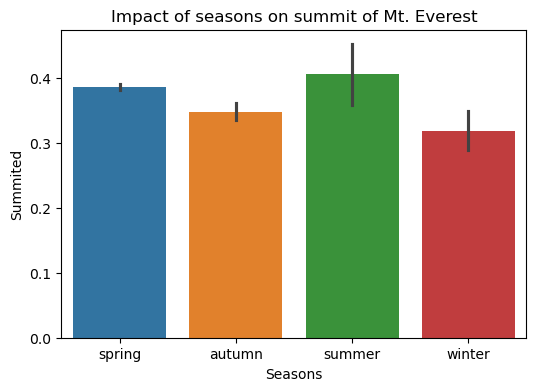

In [209]:
#summited vs season
plt.figure(figsize=(6,4))
sns.barplot(df, x="season", y="summited", hue = "season")
plt.xlabel("Seasons")
plt.ylabel("Summited")
plt.title("Impact of seasons on summit of Mt. Everest")
plt.show()

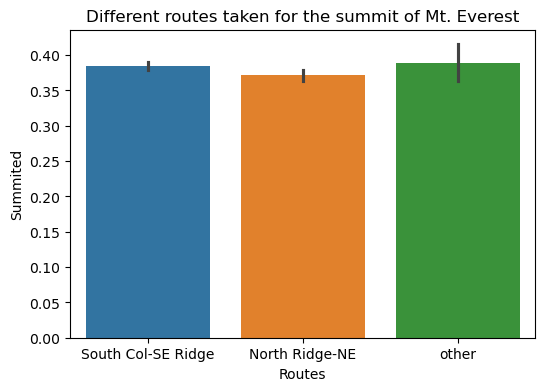

In [210]:
 #summited vs route
plt.figure(figsize=(6,4))
sns.barplot(df, x="route", y="summited", hue='route')
plt.xlabel("Routes")
plt.ylabel("Summited")
plt.title("Different routes taken for the summit of Mt. Everest")
plt.show()

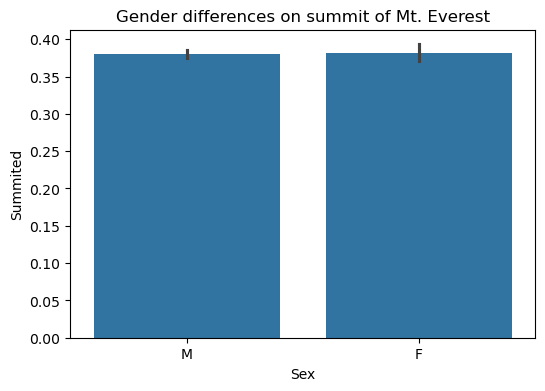

In [211]:
#summited vs sex
plt.figure(figsize=(6,4))
sns.barplot(df, x="sex", y="summited")
plt.xlabel("Sex")
plt.ylabel("Summited")
plt.title("Gender differences on summit of Mt. Everest")
plt.show()

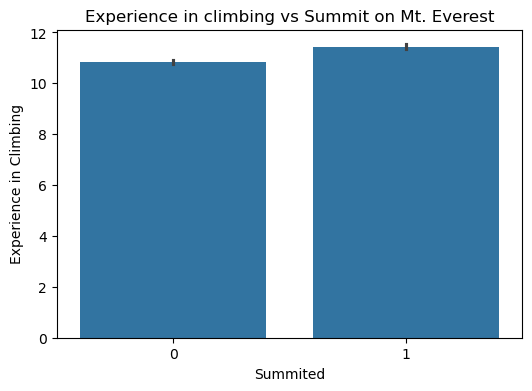

In [212]:
#Experience in climbing vs sex
plt.figure(figsize=(6,4))
sns.barplot(df, y="years_climbing", x="summited")
plt.xlabel("Summited")
plt.ylabel("Experience in Climbing")
plt.title("Experience in climbing vs Summit on Mt. Everest")
plt.show()

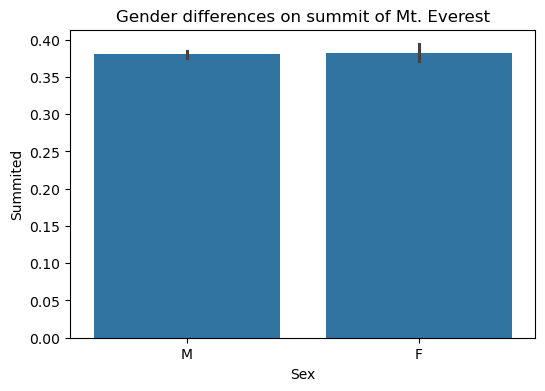

In [213]:
#summited vs sex
plt.figure(figsize=(6,4))
sns.barplot(df, x="sex", y="summited")
plt.xlabel("Sex")
plt.ylabel("Summited")
plt.title("Gender differences on summit of Mt. Everest")
plt.show()

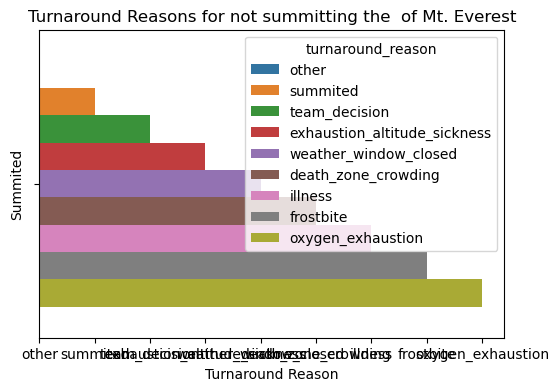

In [214]:
#summited vs Turnaround Reason
plt.figure(figsize=(6,4))
sns.barplot(df,x="turnaround_reason", hue="turnaround_reason")
plt.xlabel("Turnaround Reason")
plt.ylabel("Summited")
plt.title("Turnaround Reasons for not summitting the  of Mt. Everest")
plt.show()

In [215]:
#before we encode, let's take a backup
df_bkp = pd.DataFrame(df)


In [216]:
df_bkp.head()

,climber_id,year,season,route,age,sex,is_hired_staff,years_climbing,prior_8000m_peaks,prior_everest_attempts,...,o2_start_altitude_m,days_acclimatizing,camps_established,summit_window_days,weather_score,jetstream_risk,queue_minutes_above_8000,turnaround_reason,serious_incident,summited
0,CLB000000,2025,spring,South Col-SE Ridge,56,M,0,15,0,1,...,7000,29,6,5,10.0,1.3,120,other,0,0
1,CLB000001,2020,spring,North Ridge-NE,47,M,0,7,0,1,...,7900,27,4,5,4.8,4.7,26,summited,0,1
2,CLB000002,2022,autumn,South Col-SE Ridge,24,M,1,19,1,0,...,7000,29,3,3,8.6,1.6,37,summited,0,1
3,CLB000003,2024,spring,South Col-SE Ridge,50,F,0,12,3,0,...,7000,35,2,6,5.9,3.0,45,team_decision,0,0
4,CLB000004,2015,spring,North Ridge-NE,60,F,0,1,1,0,...,7300,20,1,7,6.7,2.7,20,exhaustion_altitude_sickness,0,0


In [217]:
col = ['season', 'route', 'operator_tier', 'sex']
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoder_array = ohe.fit_transform(df[col])

encoded_df = pd.DataFrame(
    encoder_array,
    columns=ohe.get_feature_names_out(col),
    index=df.index
)

df = pd.concat([df.drop(columns=col), encoded_df], axis=1)
df.head()

,climber_id,year,age,is_hired_staff,years_climbing,prior_8000m_peaks,prior_everest_attempts,highest_prev_altitude_m,team_size,sherpa_ratio,...,summited,season_spring,season_summer,season_winter,route_South Col-SE Ridge,route_other,operator_tier_independent,operator_tier_mid,operator_tier_premium,sex_M
0,CLB000000,2025,56,0,15,0,1,5994,16,1.30,...,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1,CLB000001,2020,47,0,7,0,1,6434,9,1.51,...,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,CLB000002,2022,24,1,19,1,0,8357,6,0.51,...,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,CLB000003,2024,50,0,12,3,0,8354,11,0.14,...,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,CLB000004,2015,60,0,1,1,0,8014,9,1.52,...,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [218]:
df.shape

(45000, 30)

Let's now build and train the data

In [219]:
#Dropping 'turnaround_reason' as it is a leakage & 'climber_id'  as it serves no purpose and 'o2_start_altitude_m', 'jetstream_risk' as they are highly correlated:
df = df.drop(columns=['turnaround_reason','climber_id','o2_start_altitude_m', 'jetstream_risk'])

df.shape

(45000, 26)

In [220]:
df.columns

Index(['year', 'age', 'is_hired_staff', 'years_climbing', 'prior_8000m_peaks',
       'prior_everest_attempts', 'highest_prev_altitude_m', 'team_size',
       'sherpa_ratio', 'uses_oxygen', 'days_acclimatizing',
       'camps_established', 'summit_window_days', 'weather_score',
       'queue_minutes_above_8000', 'serious_incident', 'summited',
       'season_spring', 'season_summer', 'season_winter',
       'route_South Col-SE Ridge', 'route_other', 'operator_tier_independent',
       'operator_tier_mid', 'operator_tier_premium', 'sex_M'],
      dtype='object')

In [221]:
#Let's split the data in x and y variables for model building
x = df.drop(columns='summited')
y = df['summited']

print(f"x_shape: {x.shape}, y_shape: {y.shape}")

x_shape: (45000, 25), y_shape: (45000,)


In [222]:
x.head()

,year,age,is_hired_staff,years_climbing,prior_8000m_peaks,prior_everest_attempts,highest_prev_altitude_m,team_size,sherpa_ratio,uses_oxygen,...,serious_incident,season_spring,season_summer,season_winter,route_South Col-SE Ridge,route_other,operator_tier_independent,operator_tier_mid,operator_tier_premium,sex_M
0,2025,56,0,15,0,1,5994,16,1.30,1,...,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1,2020,47,0,7,0,1,6434,9,1.51,1,...,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,2022,24,1,19,1,0,8357,6,0.51,1,...,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,2024,50,0,12,3,0,8354,11,0.14,1,...,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2015,60,0,1,1,0,8014,9,1.52,1,...,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [223]:
#now, let's split the data for testing
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

print(f"X train: {x_train.shape}, Y train: {y_train.shape}, X test: {x_test.shape}, Y test: {y_test.shape}")

X train: (36000, 25), Y train: (36000,), X test: (9000, 25), Y test: (9000,)


In [224]:
continuos_cols = ["year","age", "years_climbing", "prior_8000m_peaks", "prior_everest_attempts", "highest_prev_altitude_m", "team_size", "sherpa_ratio", "days_acclimatizing", "camps_established", "summit_window_days","weather_score", "queue_minutes_above_8000"]

scale = StandardScaler()
x_train = x_train.copy()
x_test = x_test.copy()

x_train[continuos_cols] = scale.fit_transform(x_train[continuos_cols])
x_test[continuos_cols] = scale.transform(x_test[continuos_cols])


In [225]:
# model building
classifier = LogisticRegression()
classifier.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [226]:
y_pred_test = classifier.predict(x_test)

In [227]:
accuracy = accuracy_score(y_test, y_pred_test)
print("Model accuracy", accuracy)

Model accuracy 0.7138888888888889


In [228]:
#confusion matrix:
print("\nConfusion Matrix (test set)\n", confusion_matrix(y_test, y_pred_test))


Confusion Matrix (test set)
 [[4614  943]
 [1632 1811]]


In [229]:
auc = roc_auc_score(y_test, classifier.predict_proba(x_test)[:,1])
print("Test AUC:", auc)

Test AUC: 0.7685836187383613


In [230]:
#plotting the ROC AUC curve

#Get probability values for the positive class (summited == 1)
y_pred_proba = classifier.predict_proba(x_test)[:,1]

In [231]:
y_pred_proba

array([0.47558039, 0.74699928, 0.14458684, ..., 0.17004432, 0.14491263,
       0.34447645], shape=(9000,))

AUC Score: 0.769


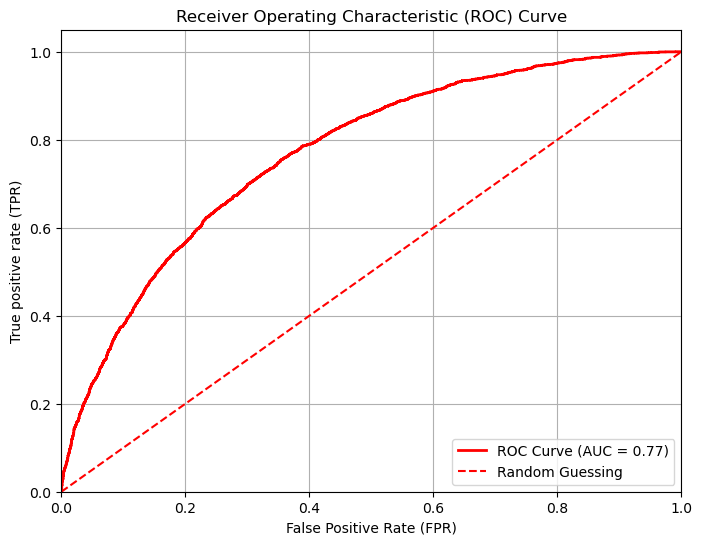

In [232]:
#Calculate the ROC curve metrics

fpr,tpr,threshold = roc_curve(y_test, y_pred_proba)

#calculate the AUC score:
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score:.3f}")

#plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color="red", lw=2, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], color= 'red', linestyle= "--", label="Random Guessing")

#Customizing plot
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True positive rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc= "lower right")
plt.grid(True)

In [233]:
y_pred_train = classifier.predict(x_train)
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train)}")

Train Accuracy: 0.7128055555555556


# Model Enhancements:

1. L2 penalty:

In [234]:
classifier_l2 = LogisticRegression(penalty="l2", C=0.1, solver="liblinear", random_state=42)
classifier_l2.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [235]:
y_pred_l2 = classifier_l2.predict(x_test)

In [236]:
accuracy = accuracy_score(y_test, y_pred_l2)
print("Accuracy Score with L2 penalty = ",accuracy)

Accuracy Score with L2 penalty =  0.714


Penalty = l2 reduces overfitting by penalizing Large coefficients.  
c=0.1 increases regularization strength (lower C = stronger penalty)

2. Recursive Feature Elimination (RFE):
Selects the top n most important features by recursively removing the least significant feature.

Why?  
Improves generalization by eliminating noisy/irrelevant features.  
Reduces training and model complexity.

In [237]:
from sklearn.feature_selection import RFE

#selects top 3 features

selector = RFE(classifier, n_features_to_select=3, step=1)
selector.fit(x_train, y_train)
print("Selection feature:", x_train.columns[selector.support_])

Selection feature: Index(['prior_8000m_peaks', 'sherpa_ratio', 'uses_oxygen'], dtype='object')


In [238]:
df_2 = df[['prior_8000m_peaks', 'sherpa_ratio', 'uses_oxygen', "summited"]]

In [239]:
df_2.shape

(45000, 4)

In [240]:
x_2 = df_2.iloc[:, :3]
y_2 = df_2.iloc[:, 3]

In [241]:
x2_train, x2_test, y2_train, y2_test = train_test_split(x_2,y_2, test_size=0.2, random_state=42)
print(f"X2 train shape: {x2_train.shape}")
print(f"X2 test shape: {x2_test.shape}")
print(f"Y2 train shape: {y2_train.shape}")
print(f"Y2 test shape: {y2_test.shape}")

X2 train shape: (36000, 3)
X2 test shape: (9000, 3)
Y2 train shape: (36000,)
Y2 test shape: (9000,)


In [242]:
continuos_cols = ['prior_8000m_peaks', 'sherpa_ratio']

scale = StandardScaler()
x2_train = x2_train.copy()
x2_test = x2_test.copy()

x2_train[continuos_cols] = scale.fit_transform(x2_train[continuos_cols])
x2_test[continuos_cols] = scale.transform(x2_test[continuos_cols])

In [243]:
classifier_rfe = LogisticRegression()
classifier_rfe.fit(x2_train, y2_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [244]:
y2_pred_test = classifier_rfe.predict(x2_test)

In [245]:
accuracy = accuracy_score(y2_test, y2_pred_test)
print("Model accuracy", accuracy)

Model accuracy 0.684


3. Cross Validation:
A method to evaluate model performance by splitting the data into multiple train-test folds  

It provides a single robust estimate of generalization error.  
Reduces reliance on single train-test split

In [246]:
from sklearn.model_selection import cross_val_score

#5-fold cross validation
cv_scores = cross_val_score(classifier, x_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validated Accuracy: {cv_scores.mean():.3f} (\u00b1 {cv_scores.std():.3f})")

Cross-Validated Accuracy: 0.712 (± 0.003)
